## GAN for MNIST

### PART 1: IMPORTS

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### PART 2: DATASET PREPARATION

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                   # it converts the images to tensors and scales the pixel values to the range [0, 1].
    transforms.Normalize((0.5,), (0.5,))     # it normalizes the data to have a mean of 0.5 and a standard deviation of 0.5, which helps in faster convergence during training and values are in the range [-1, 1].
])                                           # Normalization = scaling input values so that they have a consistent range or distribution.In deep learning we usually transform data so that it has:mean ≈ 0, standard deviation ≈ 1

Purpose: Define how to process images before feeding to network

transforms.Compose([]): Chains multiple transformations together

Step 1: transforms.ToTensor()

Converts PIL Image (0-255) to PyTorch tensor (0-1), Neural networks work better with numbers between 0 and 1 (or small ranges) instead of large numbers like 0–255.

Changes shape from (H, W) to (1, H, W) [1 means grayscale]

Step 2: transforms.Normalize((0.5,), (0.5,))

Formula: output = (input - 0.5) / 0.5

Shifts range from [0, 1] to [-1, 1]

Why? Generator uses Tanh output (range -1 to 1), so inputs should match this range

Why normalize?

Neural networks train faster if input is centered around 0 (helps gradients flow).

Generator output uses tanh which outputs values in [-1, 1].

If input images are 0–1 instead of -1–1, the discriminator sees a mismatch in scale, making training unstable.

What if we don’t normalize?

Training becomes unstable.

The generator may struggle to produce realistic images.

Loss might oscillate, GAN might not converge



In [36]:
# We only need the training set for GANs not test set, as they learn to generate data similar to the training data. The test set is typically used for evaluating the performance of a model, which is not the primary focus when training a GAN.

trainset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

trainloader = DataLoader(
    trainset, 
    batch_size=64, 
    shuffle=True
)



### PART 3: GENERATOR ARCHITECTURE

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):               # noise vector is a random vector that serves as input to the generator; The generator learns to transform this noise vector into a realistic image through training, and the noise_dim parameter specifies the dimensionality of this noise vector (i.e., how many random values it contains)
        super(Generator, self).__init__()            # super() is used to call the __init__ method of the parent class (nn.Module) to ensure that the generator class inherits all the necessary properties and methods from nn.Module, which is essential for defining a neural network in PyTorch.
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),               # input 100, output 128
            nn.ReLU(True),                           # true means in-place operation which can save memory by modifying the input directly instead of creating a new tensor for the output, and ReLU is used as the activation function to introduce non-linearity into the model, allowing it to learn more complex patterns in the data.
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),                   # output 28*28 which is the size of the generated image (28x28 pixels , MNIST)       
            nn.Tanh()                                # Tanh activation function is used to ensure that the output pixel values are in the range [-1, 1], which is suitable for image data that has been normalized to this range which we did in previous steps. And it helps the generator to produce more realistic images by allowing it to output both positive and negative values, which can capture a wider range of features in the generated images.
        )
    
    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)     # flattens the output vector to the shape of an image (batch_size, channels, height, width). In this case, it reshapes the output to have 1 channel (grayscale) and dimensions of 28x28 pixels. The -1 in the view function allows PyTorch to automatically infer any batch size based on the total number of elements in the tensor.         


What is noise_dim=100?
Think of it like this:

noise_dim = 100 means: 
"Give me 100 random numbers as my inspiration/raw material"
Analogy: The Artist's Sketch Pad
```
Imagine an artist who wants to draw a cat:

Random Scribbles (noise) → Artist's Brain → Finished Drawing
      ↓                         ↓                 ↓
  100 random              Generator           28×28 image
   numbers                (neural net)         of a digit
```     
The artist can't create from NOTHING. They need:
- Some random inspiration
- Some scribbles to start with
- Some "creative chaos" to shape into something meaningful, 
Why 100? Why not 10 or 1000?
```
noise_dim = 10   # Too small: Like giving artist only 10 scribbles
                  # Result: Can only draw 10 variations (boring!)

noise_dim = 100  # Just right: Like giving artist 100 different scribbles
                  # Result: Can draw thousands of unique digits!

noise_dim = 1000 # Too big: Too many scribbles to process
                  # Result: Confuses the artist, harder to learn
```                 
Think of it as "CREATIVE FREEDOM":

Small noise_dim = Less freedom (limited variety)

Large noise_dim = More freedom (more variety, but harder to control)

100 is the "sweet spot" that works well for MNIST

#### Generator Architecture Explained:
```
Layer	Input → Output	Purpose
Linear1	100 → 128	Expand random noise to learnable features
ReLU	128 → 128	Add non-linearity, inplace=True saves memory
Linear2	128 → 256	Further expand, more capacity to learn
ReLU	256 → 256	Non-linearity again
Linear3	256 → 784	Project to image size (28×28 = 784 pixels)
Tanh	784 → 784	Scale outputs to [-1, 1] to match normalized images
```
Why Tanh at the end?

MNIST images are normalized to [-1, 1]

Tanh outputs values in this exact range

Creates better gradients than sigmoid

```
    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)
```        
Purpose: Define forward pass

self.model(x): Pass noise through sequential layers

.view(-1, 1, 28, 28): Reshape output to image format

-1: Automatically infer batch size

1: 1 channel (grayscale)

28, 28: Height and width

Shape transformation:
```
Input noise: (batch_size, 100)
After Linear layers: (batch_size, 784)
After view: (batch_size, 1, 28, 28)  ← Ready to display as image!
```

Analogy – Noise is a “seed”

Imagine:

100 random numbers = random clay in your hand

Generator = sculptor who doesn’t know what a digit is yet

Discriminator = teacher saying “this looks real/fake”

The generator doesn’t know digits at first.

It only knows: “I want to minimize my loss (fool the discriminator).”

How it does that:

Takes random noise z.

Passes it through its layers → produces an image.

Discriminator says “fake” → compute loss.

Backpropagation adjusts weights and biases slightly so next time, output is a bit closer to fooling D.

Over thousands of iterations:

Some weights start encoding “horizontal line here”, “loop here”, etc.

All these small shifts eventually make the generator produce coherent digits.

So yes: it’s all just weight/bias updates to reduce loss, nothing more “magical” than that.

💡 Analogy:

Imagine a blind sculptor shaping clay. He gets feedback: “too pointy, too round, not enough curve.”

He adjusts hand movements (weights) little by little.

Eventually, he sculpts a realistic digit.

### PART 4: DISCRIMINATOR ARCHITECTURE

In [38]:
class Discriminator(nn.Module):                 # define discriminator class which is a neural network that takes an image as input and outputs a probability indicating whether the image is real (from the training dataset) or fake (generated by the generator).
    def __init__(self):
        super(Discriminator, self).__init__() 
        self.model = nn.Sequential(
            nn.Linear(28*28, 256),            # Layer 1: 784 → 256  (flattened output from the generator is 28*28 = 784 as input to the discriminator)
            nn.LeakyReLU(0.2, inplace=True),  # Leaky ReLU with slope 0.2 for negative inputs, slope .2 allows a small gradient when the unit is not active(negative input), which helps prevent the "dying ReLU" problem and allows the discriminator to learn from all inputs, including those that are not strongly activated.
            nn.Linear(256, 128),              # Layer 2: 256 → 128
            nn.LeakyReLU(0.2, inplace=True),  # Leaky ReLU
            nn.Linear(128, 1),                # Layer 3: 128 → 1
            nn.Sigmoid()                      # Output probability (0-1)
        )

    def forward(self, x):
        return self.model(x.view(-1, 28*28))        # flattens the input image to a vector of size 28*28 (784) before passing it through the discriminator model. The view function is used to reshape the input tensor, and -1 allows PyTorch to automatically determine the batch size based on the total number of elements in the tensor. 
                                                        # Returns: Probability tensor of shape (batch_size, 1)

Discriminator Architecture Explained:
```
Layer	Input → Output	Purpose
Linear1	784 → 256	Process flattened image
LeakyReLU(0.2)	256 → 256	Non-linearity, allows small negative values
Linear2	256 → 128	Reduce dimensions
LeakyReLU(0.2)	128 → 128	More non-linearity
Linear3	128 → 1	Single output neuron
Sigmoid	1 → 1	Output probability (0 = fake, 1 = real)
```
Why LeakyReLU instead of ReLU?

ReLU kills negative values (outputs 0)

LeakyReLU allows small negative flow (slope 0.2)

Prevents "dying neurons" in discriminator

Formula: LeakyReLU(x) = max(0.2x, x)

### PART 5: Initialize models and optimizers

In [39]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

G = Generator().to(device)                             # create an instance of the Generator class and move it to the GPU if available
D = Discriminator().to(device)

criterion = nn.BCELoss()                               # Binary Cross Entropy Loss is used for training the GAN. It measures the difference between the predicted probabilities (output of the discriminator) and the actual labels (1 for real images and 0 for fake images). The generator aims to minimize this loss by producing images that the discriminator classifies as real, while the discriminator aims to maximize this loss by correctly distinguishing between real and fake images.
optimizerG = optim.Adam(G.parameters(), lr=0.0002)     # it updates weights of the generator network based on the computed gradients from the loss function. The learning rate of 0.0002 is a common choice for training GANs, as it allows for stable convergence while avoiding issues like mode collapse or vanishing gradients.
optimizerD = optim.Adam(D.parameters(), lr=0.0002)

Purpose: Binary Cross Entropy Loss function

Formula: BCELoss = -[y_true × log(y_pred) + (1-y_true) × log(1-y_pred)]

Where: y_true = 1 for real images, 0 for fake images

y_pred = discriminator output (probability)

Why BCELoss?

Perfect for binary classification (real vs fake)

Provides strong gradients when predictions are wrong

### PART 6: TRAINING LOOP

In [ ]:
num_epochs = 8
noise_dim = 100

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(trainloader):         # Get batch of images (ignore labels _ because GANs don't need labels)
        images = images.to(device)                        # Move images to GPU
        batch_size = images.size(0)                       # Get batch size (last batch might be smaller than 64 in case)
        
        # Create real and fake labels for the discriminator
        # Real labels
        real_labels = torch.ones(batch_size, 1).to(device)      # create a tensor of ones of size (batch_size, 1) and move it to the GPU, All 1s (Discriminator should say "real")
        # Fake labels 
        fake_labels = torch.zeros(batch_size, 1).to(device)     # here (batch_size, 1) : 1 means 1 column and batch_size means number of rows to match discriminator output, and move it to the GPU, All 0s (Discriminator should say "fake"), this is just a tensor of zeros that serves as the target labels for the fake images when training the discriminator, indicating that these images are generated and should be classified as fake.

        # ---------------------
        # Train Discriminator
        # ---------------------
        outputs = D(images)                                      # Pass real images from taining dataset through discriminator to get real outputs ( should be close to 1)
        d_loss_real = criterion(outputs, real_labels)            # more close to 1 the less loss

        noise = torch.randn(batch_size, noise_dim).to(device)    # Generate random noise vector of size (batch_size, noise_dim) and move it to the GPU, which serves as input to the generator to create fake images. here noise_dim is the dimensionality of the random noise vector, and batch_size is the number of such vectors we want to generate in one batch, which matches the number of real images we are using to train the discriminator in this iteration. 
        fake_images = G(noise)                                   # Generate fake images using the generator by passing random noise through it
        outputs = D(fake_images.detach())                        # Pass fake images through discriminator to get fake outputs ( should be close to 0), detach() is used to prevent gradients from flowing back into the generator during the discriminator's training, ensuring that only the discriminator's parameters are updated when calculating the loss for fake images.
                                                                 # if we don't use detach() here, the gradients would flow back to the generator when we compute the loss for fake images, which would interfere with the generator's training and lead to unstable training dynamics in GANs.
        d_loss_fake = criterion(outputs, fake_labels)            # more close to 0 the less loss

        d_loss = d_loss_real + d_loss_fake                       # Total discriminator loss 
        optimizerD.zero_grad()                                   # Clear gradients
        d_loss.backward()                                        # Backpropagation to compute gradients for discriminator
        optimizerD.step()                                        # Update discriminator weights

        # ---------------------
        # Train Generator
        # ---------------------
        outputs = D(fake_images)                                # Pass the same fake images through discriminator again to get outputs for generator loss calculation (should be close to 1 because generator wants to fool the discriminator)
        g_loss = criterion(outputs, real_labels)                # Generator loss (we want the fake images to be classified as real, so we use real_labels here , all 1s), more close to 1 the less loss

        optimizerG.zero_grad()
        g_loss.backward()
        optimizerG.step()

    print(f"Epoch {epoch+1}, D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}")

Epoch 1, D_loss: 0.0194, G_loss: 5.1955
Epoch 2, D_loss: 0.9947, G_loss: 1.6322
Epoch 3, D_loss: 0.5183, G_loss: 2.2396
Epoch 4, D_loss: 0.1413, G_loss: 3.1720
Epoch 5, D_loss: 0.6000, G_loss: 2.5933
Epoch 6, D_loss: 0.7705, G_loss: 3.0908
Epoch 7, D_loss: 0.1115, G_loss: 4.6737
Epoch 8, D_loss: 0.7042, G_loss: 6.9929


#### What .detach() Does

.detach() cuts the computation graph.

Visual Comparison

WITHOUT detach()
```
noise
  │
  ▼
Generator
  │
  ▼
fake_images
  │
  ▼
Discriminator
  │
  ▼
loss

Backward:
loss → D → fake_images → G
```
PyTorch computes gradients through the entire graph backward.

So, Generator receives gradients ❌

What .detach() Does

.detach() cuts the computation graph.

fake_images = G(noise).detach()

Now graph becomes:
```
noise → Generator → fake_images  (STOP)
                         │
                         ▼
                   Discriminator
                         │
                         ▼
                        loss

Backpropagation:

loss → Discriminator
```
Generator is not connected anymore.

So gradients stop here: in fake_images

Generator parameters stay unchanged.

Important PyTorch detail: why don't use detach() in generator training?

Even though D gets gradients during generator training step:

D.grad is computed

But since we never run:

optimizerD.step()

those gradients are simply ignored and overwritten next iteration.

#### Results explained
Epoch 1

D_loss: 0.019

G_loss: 5.19

Discriminator is very strong.

It easily detects fake images.

So generator loss is very large.

Epoch 2

D_loss: 0.99

G_loss: 1.63

Now generator improved.

Discriminator is confused.

This is good.

Epoch 4

D_loss: 0.14

G_loss: 3.17

Discriminator got strong again.

Generator struggles.

Epoch 8

D_loss: 0.70

G_loss: 6.99

Generator is currently losing.

But this is normal for GANs.

### PART 7: Display some fake images using the trained Generator

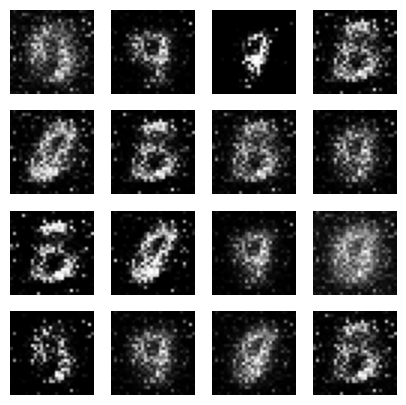

In [ ]:
noise = torch.randn(16, noise_dim).to(device)        # Generate 16 random noise vectors to create 16 fake images for visualization
fake_images = G(noise).cpu().detach()                # Generate fake images using the generator and move them back to the CPU for visualization and detach from the computation graph for visualization
plt.figure(figsize=(5,5))                            
for i in range(16):                                 
    plt.subplot(4,4,i+1)
    plt.imshow(fake_images[i].squeeze(), cmap='gray')   # Display each fake image in a 4x4 grid and squeeze() is used to remove the channel dimension (1 in this case) to display the image correctly as a 2D array, and cmap='gray' is used to display the images in grayscale since they are single-channel images.
    plt.axis('off')                                      
plt.show()

#### The GAN Objective Function

The equation :

min_G max_D V(D,G) =
E_x[log D(x)] + E_z[log(1 - D(G(z)))]

means:

Discriminator tries to MAXIMIZE this function

Generator tries to MINIMIZE it

That’s why it says:

min_G max_D

This is called a minimax game.

Break the equation into parts

First term

E_x[ log D(x) ]

Meaning:

Take real images x,
Feed them to discriminator,
D(x) should be close to 1,

Because real images should be classified as real.

So:

log(D(x)) → large (close to 0)

Second term

E_z[ log(1 - D(G(z))) ]

Steps:

z → random noise,
G(z) → fake image,
D(G(z)) → discriminator prediction,

If discriminator is correct:

D(G(z)) ≈ 0

Then:

1 - D(G(z)) ≈ 1

log(1) = 0

So the discriminator wants this term large.

What Discriminator wants

Discriminator tries to maximize (close to 0):

log D(x) + log(1 - D(G(z)))

Meaning:

Real images → output 1

Fake images → output 0

So it becomes a perfect classifier.

What Generator wants

Generator wants to fool the discriminator.

It tries to make:

D(G(z)) → 1

Meaning the discriminator believes fake images are real.

So generator tries to minimize

log(1 - D(G(z))) [becomes negative , so total value function minimizes]

What is Expectation (E)


E_x,
E_z

Expectation simply means:

Average over many samples

Example:

Instead of computing for one image:

log D(x)

We compute the average over the dataset.

So:

E_x = average over real images

E_z = average over noise samples

#### What happens at equilibrium

The theoretical perfect GAN state:

D(x) = 0.5 (equal probability for real and fake images so total probability = .5)

Why?

Because the discriminator cannot tell the difference.

So every image looks equally real.

Real image → 0.5

Fake image → 0.5

This means:

Generator is producing perfect images

"GAN training is formulated as a minimax game where the generator tries to minimize the probability that the discriminator correctly identifies fake images, while the discriminator tries to maximize its ability to distinguish real images from generated ones."

#### Why GAN training often becomes unstable and why the discriminator can overpower the generator.
1. Why GAN training becomes unstable

GAN training is unstable because two neural networks are learning at the same time and competing.

Normal neural network training:

Model → minimize loss → converge

GAN training:
```
Generator        ↔    Discriminator

tries to fool        tries to detect
```
So the optimization becomes a two-player minimax game, not a simple optimization.

Your objective again:

min_G max_D V(D,G)

This means:

Generator tries to minimize

Discriminator tries to maximize

This creates oscillation instead of convergence.

Example behavior:
```
Epoch 1 → D strong
Epoch 5 → G improves
Epoch 10 → D improves again
Epoch 15 → G catches up
```
So training becomes unstable or oscillatory.

2. Why the Discriminator can overpower the Generator

At the beginning of training:

Generator produces complete noise images

Example fake digit:

random pixels

But the discriminator sees real MNIST digits.

So distinguishing is extremely easy.

So:

D(real) ≈ 1

D(fake) ≈ 0

Meaning the discriminator becomes very confident very quickly.

3. The Gradient Problem (VERY important)

Look at the generator loss term:

log(1 − D(G(z)))

If the discriminator is very strong:

D(G(z)) ≈ 0 [catches fake perfectly]

Then:

log(1 - 0) = log(1) = 0

The gradient becomes almost zero.

This means:

Generator receives almost no learning signal

So the generator cannot improve.

##### **This is called: Vanishing gradient problem in GANs**

4. Mode Collapse (another instability)

Sometimes GAN learns only a few types of outputs.

Example:

Instead of generating many digits:

0 1 2 3 4 5 6 7 8 9

Generator learns:

7 7 7 7 7 7 7

Why?

Because it discovered one output that fools the discriminator.

So it keeps generating the same thing.

This is called:

#### Mode Collapse

Very famous GAN problem.

5. Training imbalance

Another issue:

If learning rates are wrong:

D learns too fast

or

G learns too fast

Then the game becomes unfair.

Example:

Strong D → G cannot learn

Strong G → D always fooled

Training becomes unstable.

6. Non-convergent optimization

In normal ML:

Loss → minimum

In GAN:

The system can cycle forever.

Example:

G improves → D adapts

D improves → G adapts

Like rock-paper-scissors dynamics.

7. Why modern GAN improvements exist

Because of these problems researchers created better GAN variants like:

• Wasserstein GAN (WGAN)
• WGAN-GP
• StyleGAN
• DCGAN

These improve:
```
training stability
gradient flow
image quality
```
8. Short explanation for research paper

We can write something like:

GAN training is inherently unstable because it involves a two-player minimax optimization problem where the generator and discriminator compete with each other. If the discriminator becomes too strong, it can perfectly classify fake samples, causing the generator to receive very small gradients (vanishing gradient problem). This prevents the generator from learning effectively. Additionally, GANs often suffer from mode collapse, where the generator produces limited varieties of outputs instead of capturing the full data distribution.

That paragraph is research-paper level explanation.

9. One more concept (optional but impressive)

If we want to sound very strong in our paper, we can mention:

#### Nash Equilibrium

GAN theoretically converges to:

Nash equilibrium

Where:

Generator distribution = Real data distribution

And the discriminator outputs:

0.5 for everything

```
1️⃣ Why we normalize MNIST to [-1, 1]

You already wrote the reason correctly, but the core idea is this:

Generator output layer:

nn.Tanh()

Range of tanh

[-1 , 1]

If real images are:

[0 , 1]

and fake images are:

[-1 , 1]

Then the discriminator can cheat easily.

It will simply learn:

if pixel < 0 → fake

That would make GAN training useless.

So we convert real images:

[0 , 1] → [-1 , 1]

Using

Normalize((0.5,), (0.5,))

because

(x - 0.5) / 0.5
2️⃣ Why .detach() is used here

Your code:

outputs = D(fake_images.detach())

Very important.

If we do NOT detach:

fake_images → D → loss → backprop

The gradient will update:

Generator + Discriminator

But during D training we only want to update D.

So:

fake_images.detach()

means:

stop gradient flow to Generator

So training becomes:

update D only